# Extracting precipitation data from CHIRPS

In [ ]:
import pandas as pd
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt


In [2]:
lonlat = pd.read_csv('../data/raw/locations.csv')

In [3]:
files = sorted(Path("../data/raw/chirps").glob("chirps_pcp_*.nc"))

chirps = xr.open_mfdataset(
    files,
    engine="netcdf4",
    combine="by_coords",
    parallel=False
)

In [4]:
points = lonlat.reset_index(drop=True)

lons = xr.DataArray(
    points.lon.values,
    dims="points"
)

lats = xr.DataArray(
    points.lat.values,
    dims="points"
)

In [5]:
precip = chirps["precip"].sel(
    longitude=lons,
    latitude=lats,
    method="nearest"
)

In [6]:
precip.to_dataframe().isnull().sum()

latitude        0
longitude       0
precip       4200
dtype: int64

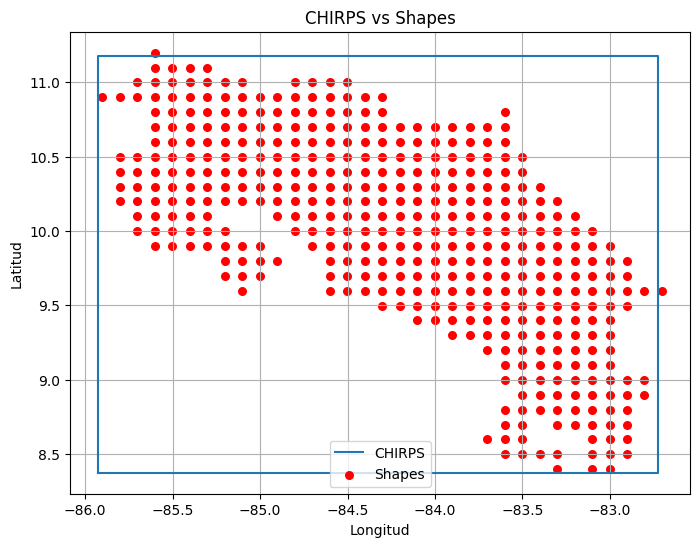

In [7]:
import matplotlib.pyplot as plt

lon_min = float(precip.longitude.min())
lon_max = float(precip.longitude.max())
lat_min = float(precip.latitude.min())
lat_max = float(precip.latitude.max())

plt.figure(figsize=(8, 6))

# Draw CHIRTS domain as a rectangle
plt.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    label="CHIRPS",
)

# Plot your points
plt.scatter(points.lon, points.lat, c="red", s=30, label="Shapes")

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()
plt.title("CHIRPS vs Shapes")
plt.grid(True)
plt.show()


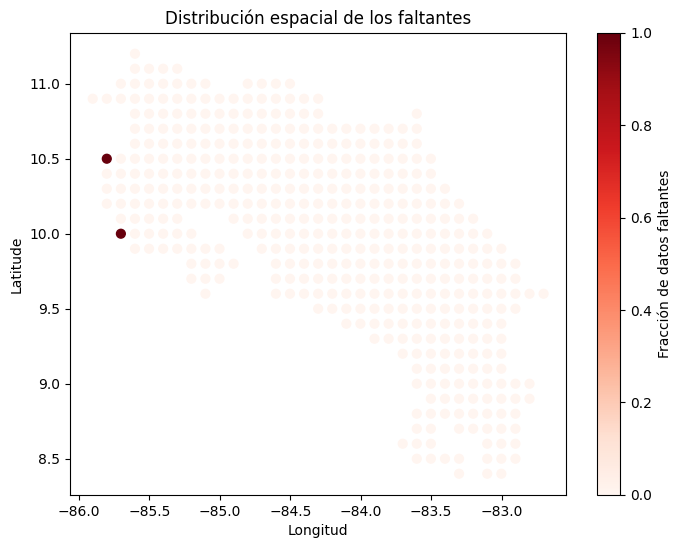

In [8]:
nan_fraction = precip.isnull().mean("time")

plt.figure(figsize=(8, 6))
plt.scatter(points.lon, points.lat, c=nan_fraction, cmap="Reds", s=40)
plt.colorbar(label="Fracción de datos faltantes")
plt.xlabel("Longitud")
plt.ylabel("Latitude")
plt.title("Distribución espacial de los faltantes")
plt.show()


In [7]:
weekly = precip.resample(time="1W")

weekly_stats = xr.Dataset({
    "prep_week_min": weekly.min(),
    "prep_week_max": weekly.max(),
    "prep_week_mean": weekly.mean(),
    "prep_week_median": weekly.median(),
    "prep_week_sum": weekly.sum()
})

datos_weekly = (
    weekly_stats
    .to_dataframe()
    .reset_index()
    .assign(
        lon=lambda df: points.loc[df["points"], "lon"].values,
        lat=lambda df: points.loc[df["points"], "lat"].values,
        canton=lambda df: points.loc[df["points"], "canton"].values
    )
    .drop(columns="points")
    .rename(columns={"time": "week"})
)

c:\Users\nan\OneDrive - Universidad de Costa Rica\cuenta personal\ucr pers\practica profesional\practica dengue\dengue-model\.venv\Lib\site-packages\dask\array\reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
c:\Users\nan\OneDrive - Universidad de Costa Rica\cuenta personal\ucr pers\practica profesional\practica dengue\dengue-model\.venv\Lib\site-packages\dask\array\reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
c:\Users\nan\OneDrive - Universidad de Costa Rica\cuenta personal\ucr pers\practica profesional\practica dengue\dengue-model\.venv\Lib\site-packages\dask\_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


In [31]:
datos_weekly.to_csv('../data/raw/chirps_precip_weekly.csv', index=False)